In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)


In [11]:
# load cleaned Dataset
df = pd.read_csv('student_dataset_cleaned.csv', index_col=0)

In [12]:
df.head(10)

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_unregistration,module_presentation_length,id_assessment,date_submitted,is_banked,score,assessment_type,date,weight,sum_click
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,?,268,1752.0,18.0,0.0,78.0,TMA,19.0,10.0,934.0
1,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,?,268,1753.0,53.0,0.0,85.0,TMA,54.0,20.0,934.0
2,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,?,268,1754.0,115.0,0.0,80.0,TMA,117.0,20.0,934.0
3,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,?,268,1755.0,164.0,0.0,85.0,TMA,166.0,20.0,934.0
4,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,?,268,1756.0,212.0,0.0,82.0,TMA,215.0,30.0,934.0
5,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,?,268,1752.0,22.0,0.0,70.0,TMA,19.0,10.0,1435.0
6,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,?,268,1753.0,52.0,0.0,68.0,TMA,54.0,20.0,1435.0
7,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,?,268,1754.0,121.0,0.0,70.0,TMA,117.0,20.0,1435.0
8,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,?,268,1755.0,164.0,0.0,64.0,TMA,166.0,20.0,1435.0
9,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,?,268,1756.0,212.0,0.0,60.0,TMA,215.0,30.0,1435.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 180662 entries, 0 to 180661
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   code_module                 180662 non-null  object 
 1   code_presentation           180662 non-null  object 
 2   id_student                  180662 non-null  int64  
 3   gender                      180662 non-null  object 
 4   region                      180662 non-null  object 
 5   highest_education           180662 non-null  object 
 6   imd_band                    180662 non-null  object 
 7   age_band                    180662 non-null  object 
 8   num_of_prev_attempts        180662 non-null  int64  
 9   studied_credits             180662 non-null  int64  
 10  disability                  180662 non-null  object 
 11  final_result                180662 non-null  object 
 12  date_registration           180662 non-null  object 
 13  date_unregistration

In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code_module,180662,7,FFF,56283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_presentation,180662,4,2014J,54493,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_student,180662.0000,NaN,NaN,NaN,704970.6127,551538.7316,3733.0000,505199.0000,585503.0000,634646.0000,2716795.0000
gender,180662,2,M,97531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,180662,13,East Anglian Region,18953,NaN,NaN,NaN,NaN,NaN,NaN,NaN
highest_education,180662,5,A Level or Equivalent,82339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imd_band,180662,11,30-40%,19957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_band,180662,3,0-35,124297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_of_prev_attempts,180662.0000,NaN,NaN,NaN,0.1465,0.4486,0.0000,0.0000,0.0000,0.0000,6.0000
studied_credits,180662.0000,NaN,NaN,NaN,77.3177,37.9248,30.0000,60.0000,60.0000,90.0000,655.0000


 Missing Values Summary:
                     Missing Count  Missing %
date_unregistration         162208    89.7900
imd_band                      7810     4.3200
date_registration               48     0.0300


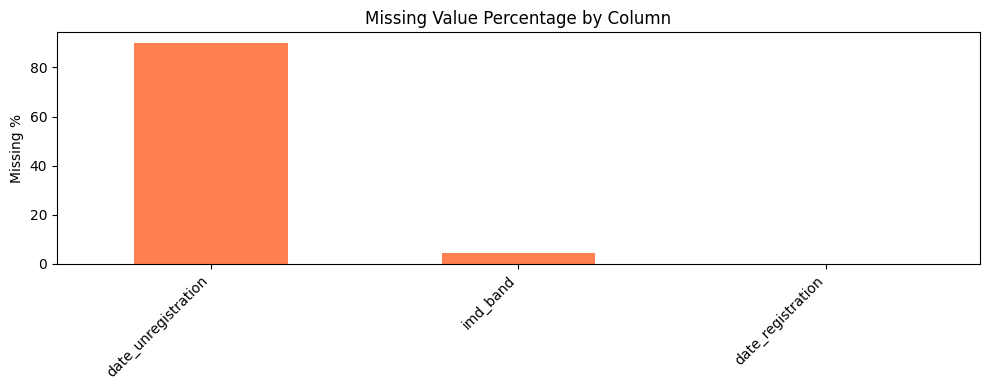

In [16]:
# 3 Missing Value Treatment
# Replace '?' placeholders with NaN (common in OULAD)
df.replace('?', np.nan, inplace=True)

# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(" Missing Values Summary:")
print(missing_df if not missing_df.empty else "✅ No missing values detected")

# Visualise
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Missing Value Percentage by Column')
    ax.set_ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [17]:
# ─── Strategy: impute by column type ─────────────────────────────────────────
for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue
    if df[col].dtype == 'object':                      # categorical → mode
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:                                               # numeric → median
        df[col].fillna(df[col].median(), inplace=True)

assert df.isnull().sum().sum() == 0, "❌ Still has nulls!"
print(" All missing values handled")

 All missing values handled


In [18]:
# 4️ Target Variable Engineering
# Inspect raw target
print(" final_result distribution:")
print(df['final_result'].value_counts())

# Binary target: Pass (1) vs At-Risk — Fail/Withdrawn (0)
df['target_pass'] = df['final_result'].apply(
    lambda x: 1 if x in ['Pass', 'Distinction'] else 0
)

# 4-class ordinal encoding
result_order = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
df['target_ordinal'] = df['final_result'].map(result_order)

print("\n Target columns created:")
print(df[['final_result', 'target_pass', 'target_ordinal']].value_counts().reset_index())

 final_result distribution:
final_result
Pass           106024
Fail            29750
Distinction     26330
Withdrawn       18558
Name: count, dtype: int64

 Target columns created:
  final_result  target_pass  target_ordinal   count
0         Pass            1               2  106024
1         Fail            0               1   29750
2  Distinction            1               3   26330
3    Withdrawn            0               0   18558


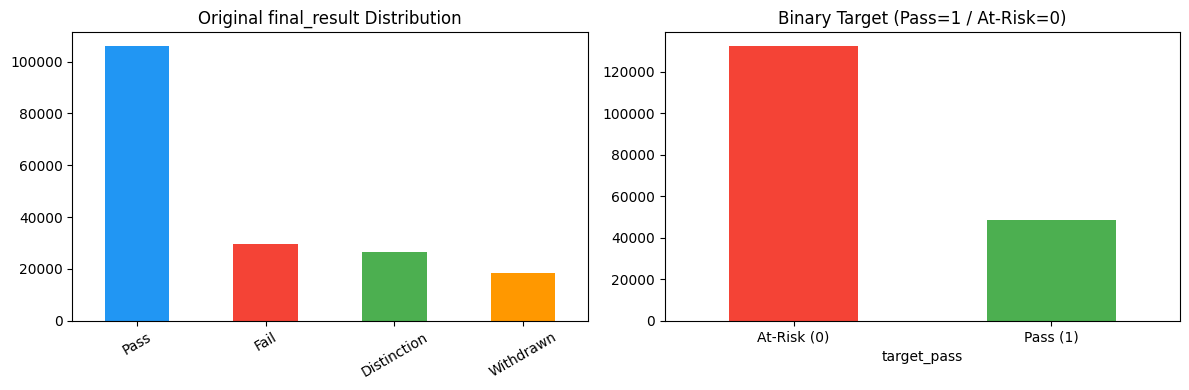

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['final_result'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3','#F44336','#4CAF50','#FF9800'])
axes[0].set_title('Original final_result Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

df['target_pass'].value_counts().plot(kind='bar', ax=axes[1], color=['#F44336','#4CAF50'])
axes[1].set_title('Binary Target (Pass=1 / At-Risk=0)')
axes[1].set_xticklabels(['At-Risk (0)', 'Pass (1)'], rotation=0)

plt.tight_layout()
plt.show()

In [20]:
# 5️ Categorical Encoding
# ── 5a. Ordinal / domain-informed mappings ────────────────────────────────────

# Education level (natural ordering)
edu_order = {
    'No Formal quals': 0,
    'Lower Than A Level': 1,
    'A Level or Equivalent': 2,
    'HE Qualification': 3,
    'Post Graduate Qualification': 4
}
df['education_level'] = df['highest_education'].map(edu_order)
df['education_level'].fillna(df['education_level'].median(), inplace=True)

# Age band (ordinal)
age_order = {'0-35': 0, '35-55': 1, '55<=': 2}
df['age_numeric'] = df['age_band'].map(age_order)

# IMD band → deprivation score (higher = less deprived)
imd_map = {
    '0-10%': 1, '10-20': 2, '20-30%': 3, '30-40%': 4,
    '40-50%': 5, '50-60%': 6, '60-70%': 7, '70-80%': 8,
    '80-90%': 9, '90-100%': 10
}
df['imd_score'] = df['imd_band'].map(imd_map)
df['imd_score'].fillna(df['imd_score'].median(), inplace=True)

# Gender binary
df['gender_binary'] = (df['gender'] == 'M').astype(int)

# Disability binary
df['disability_flag'] = (df['disability'] == 'Y').astype(int)

print(" Ordinal encodings done")
df[['highest_education','education_level','age_band','age_numeric','imd_band','imd_score']].head()

 Ordinal encodings done


,highest_education,education_level,age_band,age_numeric,imd_band,imd_score
0,HE Qualification,3,55<=,2,90-100%,10
1,HE Qualification,3,55<=,2,90-100%,10
2,HE Qualification,3,55<=,2,90-100%,10
3,HE Qualification,3,55<=,2,90-100%,10
4,HE Qualification,3,55<=,2,90-100%,10


In [21]:
# ── 5b. Label Encoding for high-cardinality columns ───────────────────────────
le = LabelEncoder()

label_encode_cols = ['code_module', 'region', 'assessment_type']
for col in label_encode_cols:
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))

print(" Label encoding done for:", label_encode_cols)

 Label encoding done for: ['code_module', 'region', 'assessment_type']


In [22]:
# ── 5c. One-Hot Encoding for nominal columns ──────────────────────────────────
ohe_cols = ['code_presentation']   # semester/year indicator — no ordinal meaning

df = pd.get_dummies(df, columns=ohe_cols, prefix=ohe_cols, drop_first=False)

# Convert boolean OHE columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(" One-Hot encoding done")
ohe_created = [c for c in df.columns if any(c.startswith(p) for p in ohe_cols)]
print("  New columns:", ohe_created)

 One-Hot encoding done
  New columns: ['code_presentation_2013B', 'code_presentation_2013J', 'code_presentation_2014B', 'code_presentation_2014J']


In [24]:
# 6️ Temporal Feature Extraction
# date_registration and date_unregistration are offsets (days from module start)
# Convert to numeric; '?' already replaced with NaN
df['date_registration'] = pd.to_numeric(df['date_registration'], errors='coerce')
df['date_unregistration'] = pd.to_numeric(df['date_unregistration'], errors='coerce')

# Early registration flag: negative value = registered before module start
df['early_registration'] = (df['date_registration'] < 0).astype(int)

# Did student unregister?
df['unregistered'] = df['date_unregistration'].notna().astype(int)

# Enrollment duration (days active before unregistration OR full module)
df['enrollment_duration'] = df.apply(
    lambda r: r['date_unregistration'] - r['date_registration']
    if not pd.isna(r['date_unregistration'])
    else r['module_presentation_length'] - r['date_registration'],
    axis=1
)
df['enrollment_duration'] = df['enrollment_duration'].clip(lower=0)

# Submission timeliness: (assessment_date - date_submitted) → positive = early
df['submission_timeliness'] = df['date'] - df['date_submitted']

# Module completion ratio: proportion of module covered at assessment date
df['module_completion_ratio'] = (df['date'] / df['module_presentation_length']).clip(0, 1)

print(" Temporal features created")
df[['early_registration','unregistered','enrollment_duration',
    'submission_timeliness','module_completion_ratio']].describe()

 Temporal features created


,early_registration,unregistered,enrollment_duration,submission_timeliness,module_completion_ratio
count,180662.0000,180662.0000,180662.0000,180662.0000,180662.0000
mean,0.9929,1.0000,87.1934,14.4885,0.5115
std,0.0838,0.0000,60.1442,47.4929,0.2964
min,0.0000,1.0000,0.0000,-372.0000,0.0513
25%,1.0000,1.0000,41.0000,-2.0000,0.2199
50%,1.0000,1.0000,70.0000,1.0000,0.4924
75%,1.0000,1.0000,118.0000,9.0000,0.8291
max,1.0000,1.0000,531.0000,246.0000,1.0000


In [25]:
# 7️ Domain-Specific Derived Features
# ── 7a. Assessment Performance Features ───────────────────────────────────────

# Weighted score = score × weight (assessment contribution to final grade)
df['weighted_score'] = df['score'] * df['weight'] / 100

# Score deviation from module average (peer comparison)
module_mean_score = df.groupby('code_module_encoded')['score'].transform('mean')
df['score_vs_module_avg'] = df['score'] - module_mean_score

# Score tier: Distinction / Pass / Fail
df['score_tier'] = pd.cut(df['score'],
                           bins=[-1, 39, 54, 69, 100],
                           labels=[0, 1, 2, 3])  # Fail / Pass / Merit / Distinction
df['score_tier'] = df['score_tier'].astype(int)

print(" Assessment features:", ['weighted_score','score_vs_module_avg','score_tier'])

 Assessment features: ['weighted_score', 'score_vs_module_avg', 'score_tier']


In [26]:
# ── 7b. Engagement / Study Behaviour Features ─────────────────────────────────

# Click density: total clicks per day of enrollment
df['click_density'] = df['sum_click'] / (df['enrollment_duration'] + 1)  # +1 avoids /0

# Study efficiency proxy: weighted_score per unit of click activity
df['study_efficiency'] = df['weighted_score'] / (df['sum_click'] + 1)

# High engager flag: sum_click > 75th percentile
click_75th = df['sum_click'].quantile(0.75)
df['high_engager'] = (df['sum_click'] > click_75th).astype(int)

# Repeat attempter flag
df['repeat_attempter'] = (df['num_of_prev_attempts'] > 0).astype(int)

# Heavy course load: studied_credits above median
df['heavy_course_load'] = (df['studied_credits'] > df['studied_credits'].median()).astype(int)

print(" Engagement features:", ['click_density','study_efficiency','high_engager',
                                    'repeat_attempter','heavy_course_load'])

 Engagement features: ['click_density', 'study_efficiency', 'high_engager', 'repeat_attempter', 'heavy_course_load']


In [27]:
# ── 7c. Student-level Aggregated Features (per student across assessments) ────

student_agg = df.groupby('id_student').agg(
    student_avg_score=('score', 'mean'),
    student_score_std=('score', 'std'),
    student_total_clicks=('sum_click', 'sum'),
    student_num_assessments=('id_assessment', 'count'),
    student_avg_weighted_score=('weighted_score', 'mean'),
    student_avg_timeliness=('submission_timeliness', 'mean')
).reset_index()

student_agg['student_score_std'].fillna(0, inplace=True)  # single-assessment students

df = df.merge(student_agg, on='id_student', how='left')

print(" Student-level aggregated features merged")
student_agg.head()

 Student-level aggregated features merged


,id_student,student_avg_score,student_score_std,student_total_clicks,student_num_assessments,student_avg_weighted_score,student_avg_timeliness
0,3733,80.0000,0.0000,1252.0000,1,7.2000,13.0000
1,6516,61.8000,10.3296,13955.0000,5,12.7000,2.6000
2,8462,87.0000,4.4721,1978.0000,7,11.1286,34.1429
3,11391,82.0000,3.0822,4670.0000,5,16.4800,1.8000
4,23629,82.5000,20.2731,644.0000,4,4.1725,-3.5000


In [28]:
# ── 7d. Module-level Context Features ────────────────────────────────────────

module_agg = df.groupby('code_module_encoded').agg(
    module_avg_score=('score', 'mean'),
    module_pass_rate=('target_pass', 'mean'),
    module_avg_clicks=('sum_click', 'mean')
).reset_index()

df = df.merge(module_agg, on='code_module_encoded', how='left')

# Relative performance within module
df['relative_score_in_module'] = df['score'] / (df['module_avg_score'] + 1e-9)

print(" Module-level features merged")

 Module-level features merged


In [30]:
# 8️ Feature Summary Before Scaling
engineered_features = [
    # Encoded categorical
    'education_level', 'age_numeric', 'imd_score',
    'gender_binary', 'disability_flag',
    'code_module_encoded', 'region_encoded', 'assessment_type_encoded',
    # Temporal
    'early_registration', 'unregistered', 'enrollment_duration',
    'submission_timeliness', 'module_completion_ratio',
    # Assessment
    'weighted_score', 'score_vs_module_avg', 'score_tier',
    # Engagement
    'click_density', 'study_efficiency', 'high_engager',
    'repeat_attempter', 'heavy_course_load',
    # Aggregated
    'student_avg_score', 'student_score_std', 'student_total_clicks',
    'student_num_assessments', 'student_avg_weighted_score', 'student_avg_timeliness',
    # Module context
    'module_avg_score', 'module_pass_rate', 'module_avg_clicks', 'relative_score_in_module',
    # Raw numerics (retained)
    'num_of_prev_attempts', 'studied_credits', 'score',
    'sum_click', 'weight', 'module_presentation_length'
]

# Keep only existing columns (guard against any skipped steps)
engineered_features = [f for f in engineered_features if f in df.columns]

feat_df = df[engineered_features].copy()
print(f" Total engineered features: {len(engineered_features)}")
feat_df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

 Total engineered features: 37


,count,mean,std,min,25%,50%,75%,max
education_level,180662.000000,1.792912,0.748091,0.000000,1.000000,2.000000,2.000000,4.000000
age_numeric,180662.000000,0.318573,0.479842,0.000000,0.000000,0.000000,1.000000,2.000000
imd_score,180662.000000,5.342883,2.766849,1.000000,3.000000,5.000000,8.000000,10.000000
gender_binary,180662.000000,0.539853,0.498411,0.000000,0.000000,1.000000,1.000000,1.000000
disability_flag,180662.000000,0.088170,0.283543,0.000000,0.000000,0.000000,0.000000,1.000000
code_module_encoded,180662.000000,3.269858,1.806258,0.000000,1.000000,3.000000,5.000000,6.000000
region_encoded,180662.000000,5.855958,3.687607,0.000000,3.000000,6.000000,9.000000,12.000000
assessment_type_encoded,180662.000000,1.191789,0.967354,0.000000,0.000000,2.000000,2.000000,2.000000
early_registration,180662.000000,0.992926,0.083809,0.000000,1.000000,1.000000,1.000000,1.000000
unregistered,180662.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [31]:
# 9️ Normalization & Scaling
# Columns that benefit from StandardScaler (unbounded, continuous)
std_scale_cols = [
    'enrollment_duration', 'submission_timeliness', 'score_vs_module_avg',
    'click_density', 'study_efficiency', 'student_avg_score', 'student_score_std',
    'student_total_clicks', 'student_avg_weighted_score', 'student_avg_timeliness',
    'relative_score_in_module', 'weighted_score', 'sum_click'
]
std_scale_cols = [c for c in std_scale_cols if c in feat_df.columns]

# Columns that benefit from MinMaxScaler (bounded, ratio-like)
minmax_scale_cols = [
    'score', 'module_completion_ratio', 'module_pass_rate',
    'imd_score', 'education_level', 'module_avg_score', 'module_avg_clicks'
]
minmax_scale_cols = [c for c in minmax_scale_cols if c in feat_df.columns]

scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()

feat_df_scaled = feat_df.copy()
feat_df_scaled[std_scale_cols]    = scaler_std.fit_transform(feat_df[std_scale_cols])
feat_df_scaled[minmax_scale_cols] = scaler_mm.fit_transform(feat_df[minmax_scale_cols])

print(" Scaling applied")
print(f"  StandardScaler → {len(std_scale_cols)} features")
print(f"  MinMaxScaler   → {len(minmax_scale_cols)} features")
feat_df_scaled.describe().T[['mean','std','min','max']].head(15)

 Scaling applied
  StandardScaler → 13 features
  MinMaxScaler   → 7 features


,mean,std,min,max
education_level,0.4482,0.1870,0.0000,1.0000
age_numeric,0.3186,0.4798,0.0000,2.0000
imd_score,0.4825,0.3074,0.0000,1.0000
gender_binary,0.5399,0.4984,0.0000,1.0000
disability_flag,0.0882,0.2835,0.0000,1.0000
code_module_encoded,3.2699,1.8063,0.0000,6.0000
region_encoded,5.8560,3.6876,0.0000,12.0000
assessment_type_encoded,1.1918,0.9674,0.0000,2.0000
early_registration,0.9929,0.0838,0.0000,1.0000
unregistered,1.0000,0.0000,1.0000,1.0000


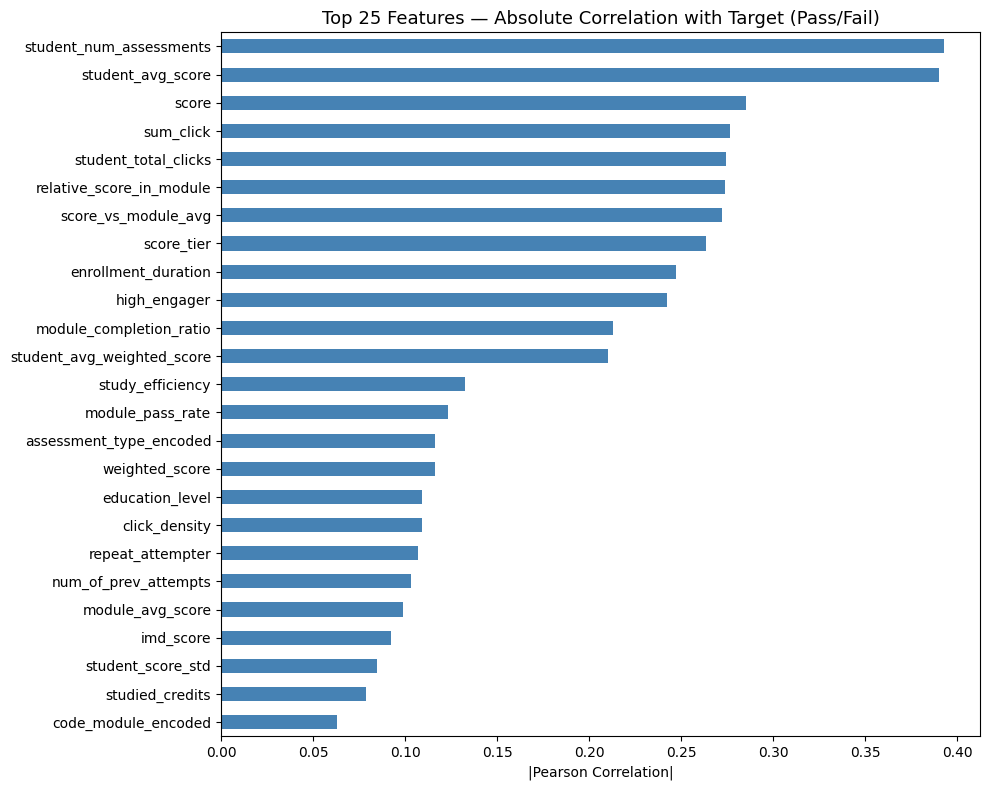

In [32]:
# 10 Feature Correlation Analysis
target = df.loc[feat_df.index, 'target_pass']

corr_with_target = feat_df_scaled.corrwith(target).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.head(25).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 25 Features — Absolute Correlation with Target (Pass/Fail)', fontsize=13)
ax.set_xlabel('|Pearson Correlation|')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

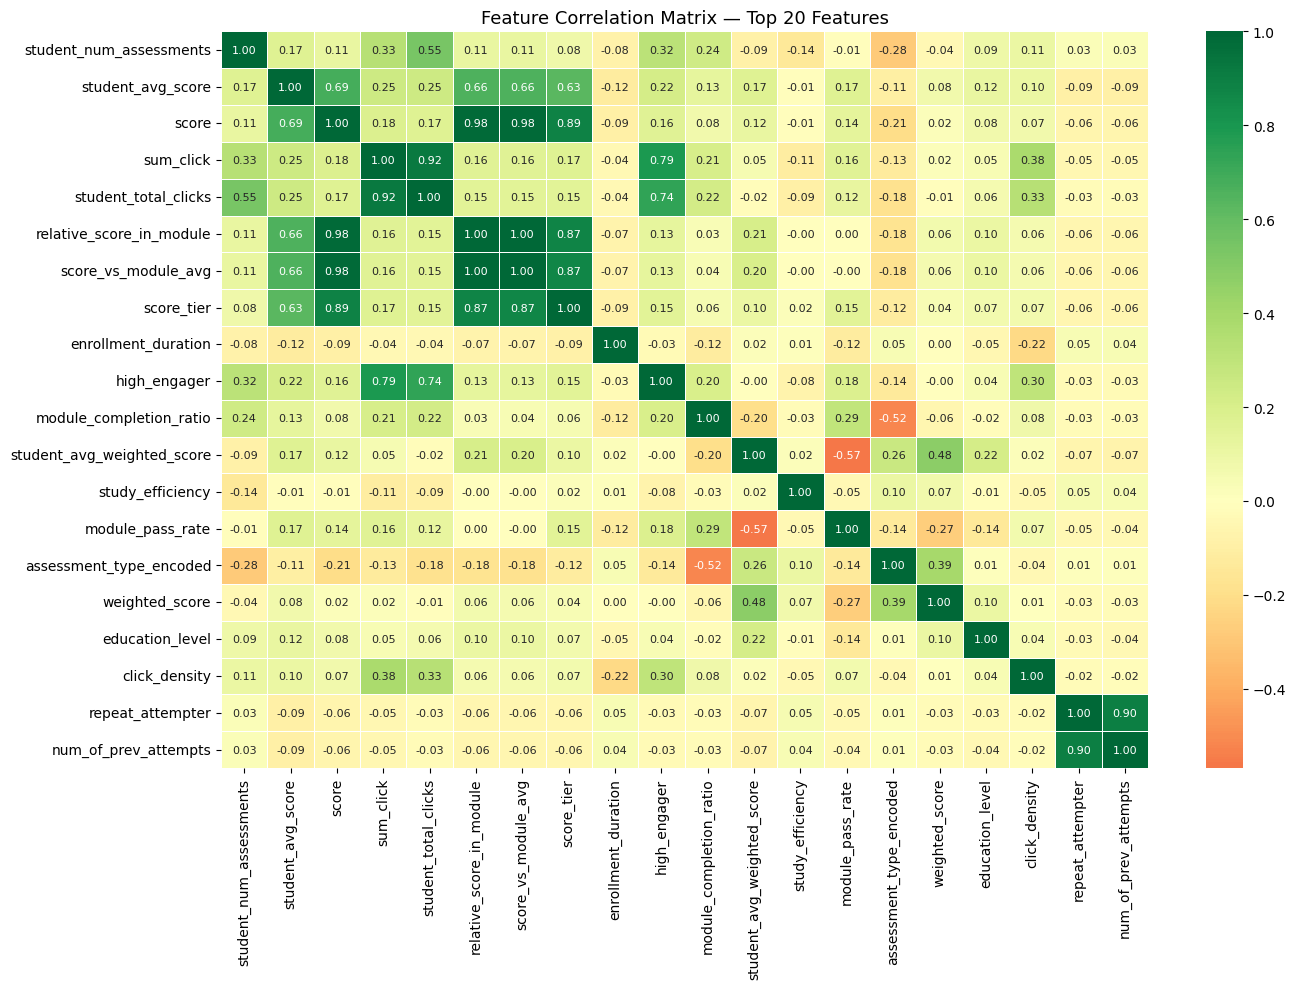

In [33]:
# Full correlation heatmap (top features only for readability)
top_feats = corr_with_target.head(20).index.tolist()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    feat_df_scaled[top_feats].corr(),
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Feature Correlation Matrix — Top 20 Features', fontsize=13)
plt.tight_layout()
plt.show()

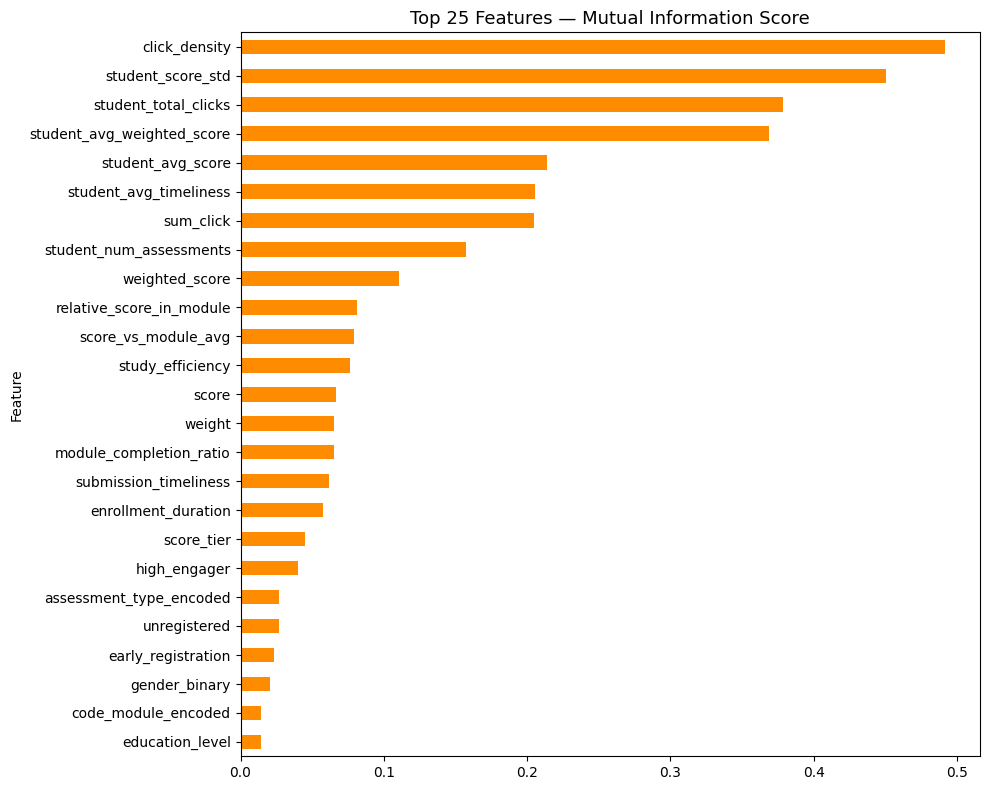


🏆 Top 10 Features by Mutual Information:
                   Feature  MI Score
             click_density    0.4915
         student_score_std    0.4503
      student_total_clicks    0.3783
student_avg_weighted_score    0.3690
         student_avg_score    0.2142
    student_avg_timeliness    0.2053
                 sum_click    0.2048
   student_num_assessments    0.1572
            weighted_score    0.1105
  relative_score_in_module    0.0811


In [34]:
#1️1️ Mutual Information — Feature Importance
from sklearn.feature_selection import mutual_info_classif

# Use unscaled for MI (MI is scale-invariant)
X_mi = feat_df.fillna(0)
y_mi = target.values

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.DataFrame({'Feature': feat_df.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))
mi_df.head(25).plot(kind='barh', x='Feature', y='MI Score', ax=ax, color='darkorange', legend=False)
ax.set_title('Top 25 Features — Mutual Information Score', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n Top 10 Features by Mutual Information:")
print(mi_df.head(10).to_string(index=False))

In [36]:
# 1️2️ Detect Highly Correlated Feature Pairs (Redundancy Check)
THRESHOLD = 0.90

corr_matrix = feat_df_scaled.corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if pd.notna(upper_tri.loc[row, col]) and upper_tri.loc[row, col] > THRESHOLD
]

if high_corr_pairs:
    hc_df = pd.DataFrame(high_corr_pairs, columns=['Feature A', 'Feature B', 'Correlation'])
    hc_df = hc_df.sort_values('Correlation', ascending=False)
    print(f"  {len(hc_df)} pairs with |r| > {THRESHOLD} (candidates for removal):")
    print(hc_df.to_string(index=False))
else:
    print(f" No feature pairs exceed correlation threshold of {THRESHOLD}")

  5 pairs with |r| > 0.9 (candidates for removal):
               Feature A                Feature B  Correlation
relative_score_in_module      score_vs_module_avg       0.9991
                   score      score_vs_module_avg       0.9846
                   score relative_score_in_module       0.9837
                  weight           weighted_score       0.9404
               sum_click     student_total_clicks       0.9204


In [37]:
# Auto-drop the less informative feature from each highly-correlated pair
features_to_drop = set()
for feat_a, feat_b, _ in high_corr_pairs:
    # Keep whichever has higher MI score; drop the other
    mi_a = mi_df.loc[mi_df['Feature'] == feat_a, 'MI Score'].values
    mi_b = mi_df.loc[mi_df['Feature'] == feat_b, 'MI Score'].values
    mi_a = mi_a[0] if len(mi_a) else 0
    mi_b = mi_b[0] if len(mi_b) else 0
    features_to_drop.add(feat_b if mi_a >= mi_b else feat_a)

print(f"  Dropping {len(features_to_drop)} redundant features: {features_to_drop}")
feat_df_final = feat_df_scaled.drop(columns=list(features_to_drop), errors='ignore')
print(f" Final feature count: {feat_df_final.shape[1]}")

  Dropping 4 redundant features: {'sum_click', 'score', 'weight', 'score_vs_module_avg'}
 Final feature count: 33


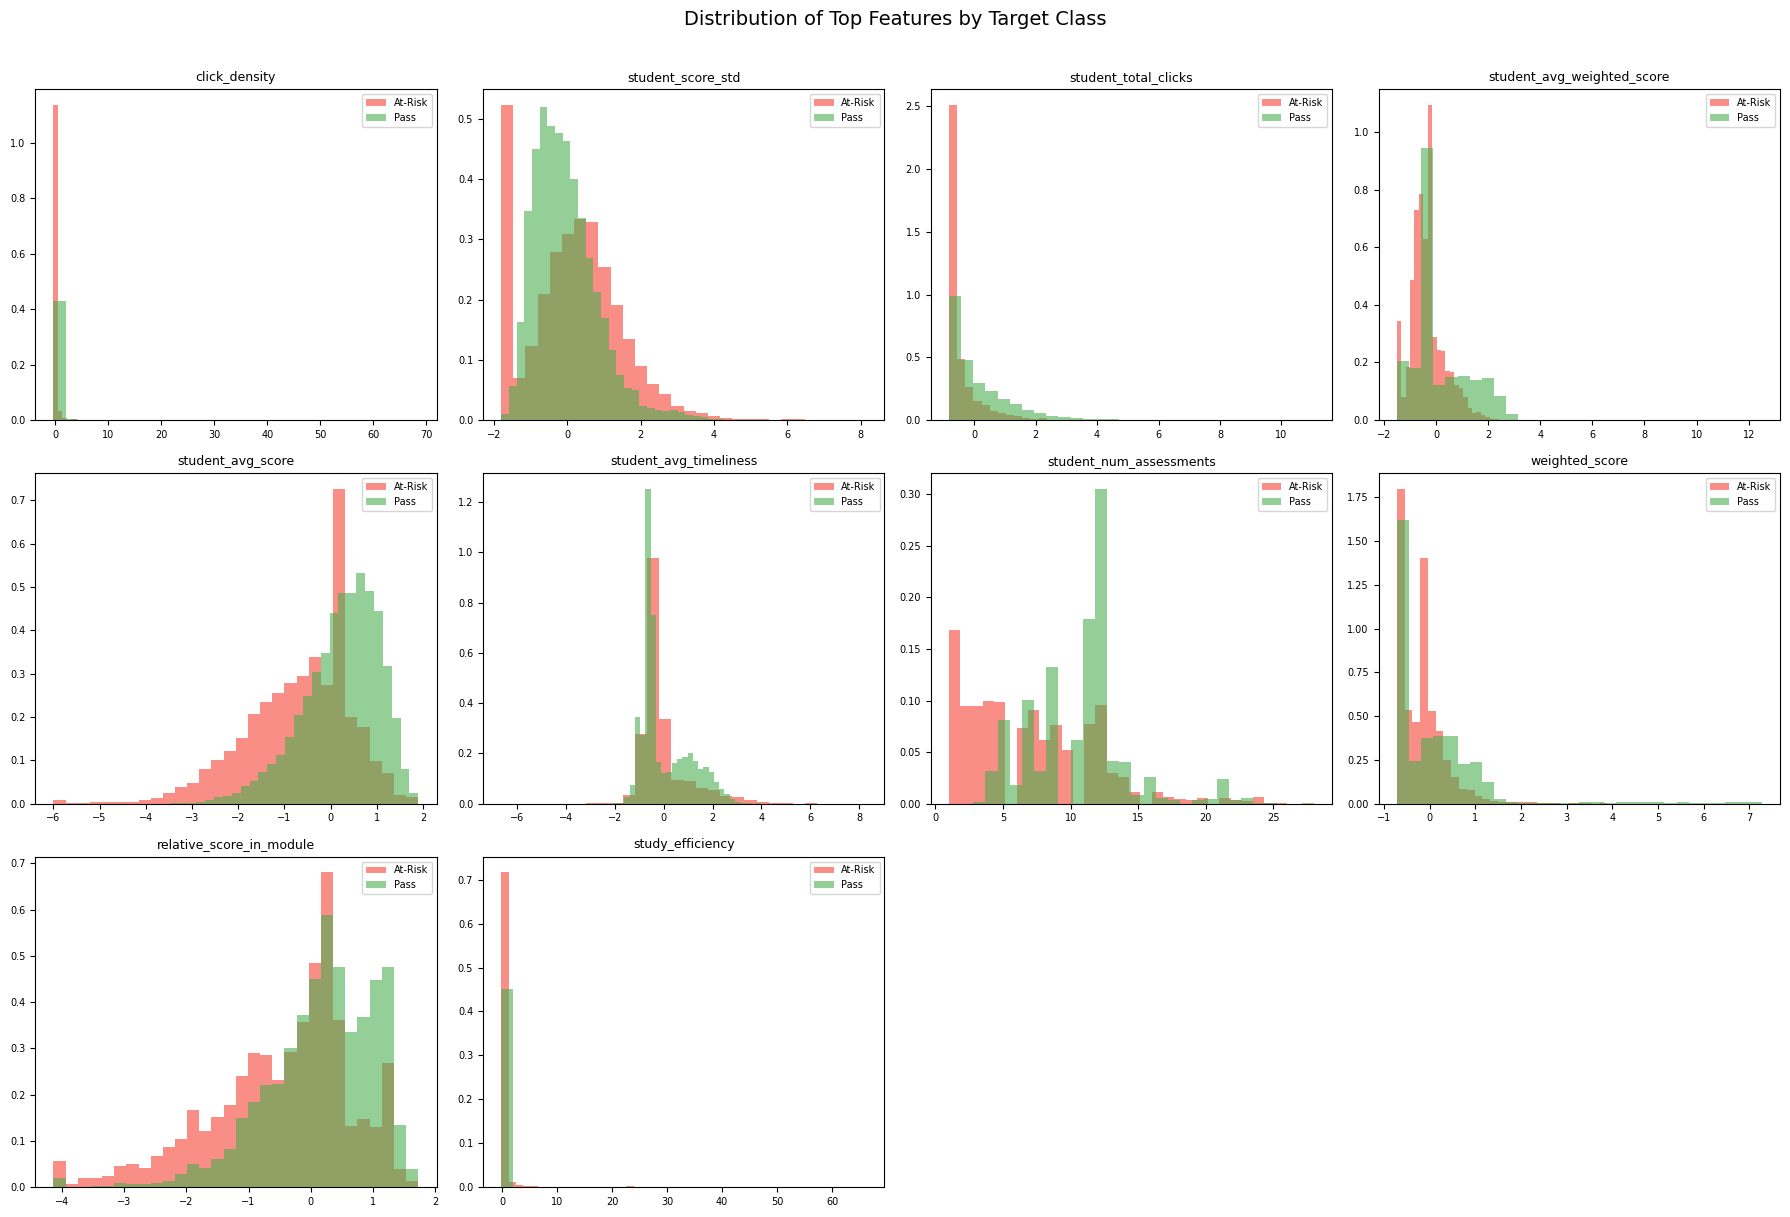

In [38]:
# 1️3️ Feature Distribution Plots
plot_feats = mi_df.head(12)['Feature'].tolist()
plot_feats = [f for f in plot_feats if f in feat_df_final.columns]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(plot_feats):
    ax = axes[i]
    for label, color in [(0, '#F44336'), (1, '#4CAF50')]:
        subset = feat_df_final.loc[target == label, feat].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label='Pass' if label==1 else 'At-Risk', density=True)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Top Features by Target Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

 Feature Stability (CV across presentations):
                       CV (lower = more stable)
score                                    0.0096
sum_click                                0.1220
weighted_score                           0.1921
submission_timeliness                    0.2180
study_efficiency                         0.2919


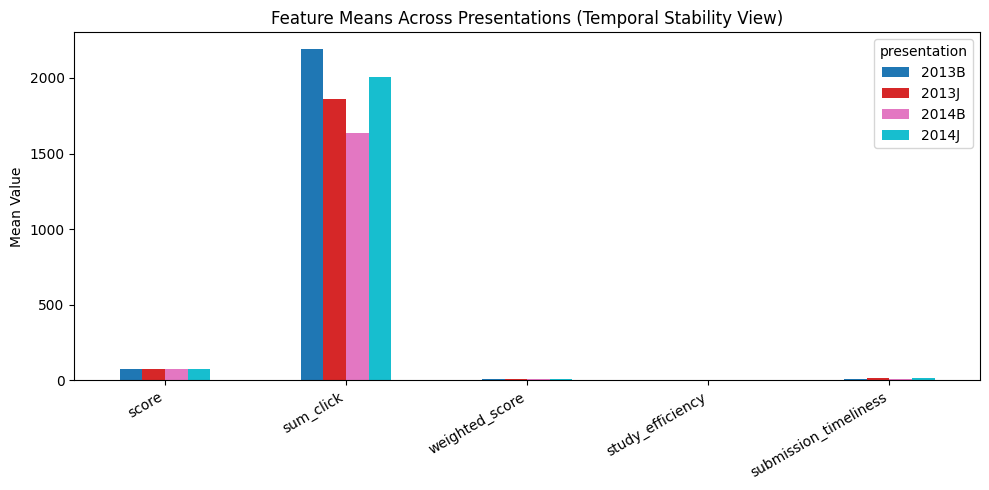

In [39]:
# 1️4️ Temporal Stability Analysis (Feature Drift Across Presentations)
# Use OHE presentation columns to detect which presentation each row belongs to
pres_cols = [c for c in df.columns if c.startswith('code_presentation_')]

if pres_cols:
    df['presentation'] = df[pres_cols].idxmax(axis=1).str.replace('code_presentation_', '')
else:
    # Fallback: if OHE not in df, re-read original column
    df['presentation'] = 'Unknown'

stability_feats = ['score', 'sum_click', 'weighted_score',
                    'study_efficiency', 'submission_timeliness']
stability_feats = [f for f in stability_feats if f in df.columns]

# Mean per presentation
pres_means = df.groupby('presentation')[stability_feats].mean()

# Coefficient of Variation (CV) across presentations → stability metric
cv = (pres_means.std() / pres_means.mean()).rename('CV (lower = more stable)')

print(" Feature Stability (CV across presentations):")
print(cv.sort_values().to_frame().to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
pres_means[stability_feats].T.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Feature Means Across Presentations (Temporal Stability View)')
ax.set_ylabel('Mean Value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [41]:
# 1️5️ Assemble & Export Final Dataset
# Attach targets and identifiers to the final feature set
final_df = feat_df_final.copy()
final_df['id_student']    = df['id_student'].values
final_df['target_pass']   = target.values
final_df['target_ordinal']= df['target_ordinal'].values

print(f"🏁 Final dataset shape: {final_df.shape}")
print(f"   Features : {final_df.shape[1] - 3}")
print(f"   Rows     : {final_df.shape[0]:,}")
final_df.head(10)

🏁 Final dataset shape: (180662, 36)
   Features : 33
   Rows     : 180,662


,education_level,age_numeric,imd_score,gender_binary,disability_flag,code_module_encoded,region_encoded,assessment_type_encoded,early_registration,unregistered,enrollment_duration,submission_timeliness,module_completion_ratio,weighted_score,score_tier,click_density,study_efficiency,high_engager,repeat_attempter,heavy_course_load,student_avg_score,student_score_std,student_total_clicks,student_num_assessments,student_avg_weighted_score,student_avg_timeliness,module_avg_score,module_pass_rate,module_avg_clicks,relative_score_in_module,num_of_prev_attempts,studied_credits,module_presentation_length,id_student,target_pass,target_ordinal
0,0.7500,2,1.0000,1,0,0,0,2,1,1,1.3934,-0.2840,0.0207,-0.0983,3,-0.3325,-0.0940,0,0,1,0.4770,-1.3591,-0.6373,5,1.2421,-0.4743,0.0000,1.0000,0.4199,0.5278,0,240,268,11391,1,2
1,0.7500,2,1.0000,1,0,0,0,2,1,1,1.3934,-0.2840,0.1583,0.6368,3,-0.3325,-0.0313,0,0,1,0.4770,-1.3591,-0.6373,5,1.2421,-0.4743,0.0000,1.0000,0.4199,0.9470,0,240,268,11391,1,2
2,0.7500,2,1.0000,1,0,0,0,2,1,1,1.3934,-0.2630,0.4061,0.5569,3,-0.3325,-0.0381,0,0,1,0.4770,-1.3591,-0.6373,5,1.2421,-0.4743,0.0000,1.0000,0.4199,0.6475,0,240,268,11391,1,2
3,0.7500,2,1.0000,1,0,0,0,2,1,1,1.3934,-0.2630,0.5988,0.6368,3,-0.3325,-0.0313,0,0,1,0.4770,-1.3591,-0.6373,5,1.2421,-0.4743,0.0000,1.0000,0.4199,0.9470,0,240,268,11391,1,2
4,0.7500,2,1.0000,1,0,0,0,2,1,1,1.3934,-0.2419,0.7915,1.2441,3,-0.3325,0.0206,0,0,1,0.4770,-1.3591,-0.6373,5,1.2421,-0.4743,0.0000,1.0000,0.4199,0.7673,0,240,268,11391,1,2
5,0.7500,1,0.2222,0,0,0,6,2,1,1,-0.3690,-0.3682,0.0207,-0.1623,3,-0.1512,-0.1161,0,0,0,-0.7551,-1.1810,-0.5407,5,0.6752,-0.5415,0.0000,1.0000,0.4199,0.0486,0,60,268,28400,1,2
6,0.7500,1,0.2222,0,0,0,6,2,1,1,-0.3690,-0.2630,0.1583,0.3651,2,-0.1512,-0.0868,0,0,0,-0.7551,-1.1810,-0.5407,5,0.6752,-0.5415,0.0000,1.0000,0.4199,-0.0712,0,60,268,28400,1,2
7,0.7500,1,0.2222,0,0,0,6,2,1,1,-0.3690,-0.3893,0.4061,0.3971,3,-0.1512,-0.0850,0,0,0,-0.7551,-1.1810,-0.5407,5,0.6752,-0.5415,0.0000,1.0000,0.4199,0.0486,0,60,268,28400,1,2
8,0.7500,1,0.2222,0,0,0,6,2,1,1,-0.3690,-0.2630,0.5988,0.3012,2,-0.1512,-0.0904,0,0,0,-0.7551,-1.1810,-0.5407,5,0.6752,-0.5415,0.0000,1.0000,0.4199,-0.3108,0,60,268,28400,1,2
9,0.7500,1,0.2222,0,0,0,6,2,1,1,-0.3690,-0.2419,0.7915,0.7167,2,-0.1512,-0.0673,0,0,0,-0.7551,-1.1810,-0.5407,5,0.6752,-0.5415,0.0000,1.0000,0.4199,-0.5503,0,60,268,28400,1,2


In [42]:
final_df.to_csv("student_features_engineered.csv")